<a href="https://colab.research.google.com/github/msr524/SWYNEX-Exploratory-Data-Analysis/blob/main/SWYNEX_DATA_CLEANING_PROJETC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv('/content/dirty_cafe_sales.csv')
print("original data shape")
df.head()
#df.info()
#df.unique()
# Count values across multiple columns
column_counts = df["Item"].value_counts(dropna=True)
print(column_counts)


original data shape
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64


In [ ]:
df.replace(['UNKNOWN','ERROR'],pd.NA,inplace=True)
df=df.dropna()

In [ ]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")

if 'Price Per Unit' in df.columns:
    df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

if 'Quantity' in df.columns:
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

df = df.dropna(subset=['Price Per Unit', 'Quantity'])

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.title()

df.to_csv('cleaned_dataset.csv', index=False)

print("\n--- Data Cleaning Complete! ---")
print("New Data Shape:", df.shape)
print("\nFirst 5 rows of your clean data:")
display(df.head())

Removed 0 duplicate rows.

--- Data Cleaning Complete! ---
New Data Shape: (3089, 8)

First 5 rows of your clean data:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Txn_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Txn_4977031,Cake,4,3.0,12.0,Cash,In-Store,2023-05-16
4,Txn_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-Store,2023-06-11
10,Txn_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07
12,Txn_7619095,Sandwich,2,4.0,8.0,Cash,In-Store,2023-05-03


--- 1. SUMMARY STATISTICS ---
          Quantity  Price Per Unit  Total Spent
count  3089.000000     3089.000000  3089.000000
mean      3.023632        2.954030     8.936711
std       1.418931        1.292975     6.032656
min       1.000000        1.000000     1.000000
25%       2.000000        2.000000     4.000000
50%       3.000000        3.000000     8.000000
75%       4.000000        4.000000    12.000000
max       5.000000        5.000000    25.000000


--- 2. GENERATED INSIGHTS ---
1. Total transaction records analyzed: 3089
2. Overall total revenue generated: 27605.5
3. Most frequently ordered item: Juice
4. Item generating the highest total revenue: Salad
5. Average transaction value: 8.94




/tmp/ipykernel_2232/1756757068.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Item', y='Total Spent', data=df, estimator=sum, ci=None, palette='Blues_d')
/tmp/ipykernel_2232/1756757068.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Item', y='Total Spent', data=df, estimator=sum, ci=None, palette='Blues_d')


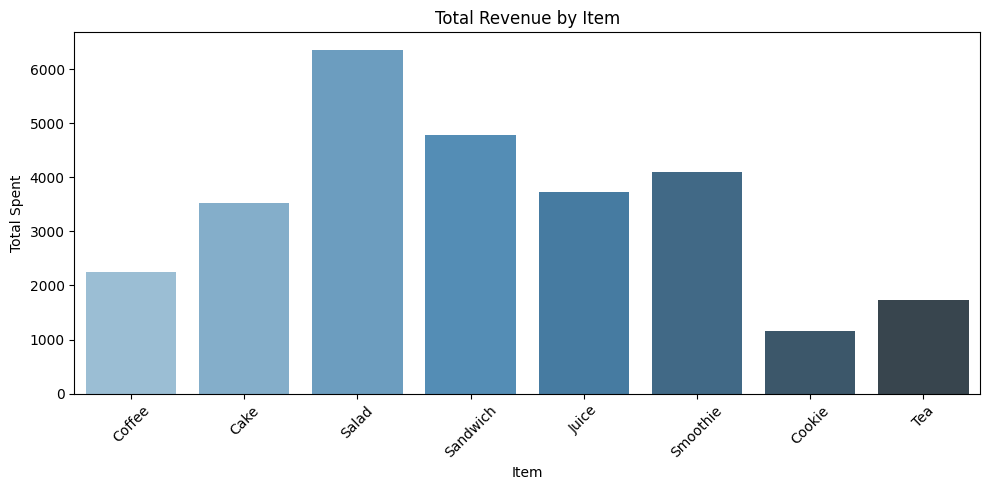

--- Analysis Complete! Charts saved to your Colab environment. ---


<Figure size 800x500 with 0 Axes>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned dataset
df = pd.read_csv('/content/cleaned_dataset.csv')

print("--- 1. SUMMARY STATISTICS ---")
print(df.describe())
print("\n")

# 2. Extract and print insights automatically
total_records = len(df)
top_item = df['Item'].value_counts().idxmax() if 'Item' in df.columns else "N/A"
highest_revenue_item = df.groupby('Item')['Total Spent'].sum().idxmax() if 'Item' in df.columns and 'Total Spent' in df.columns else "N/A"
total_revenue = df['Total Spent'].sum() if 'Total Spent' in df.columns else 0

print("--- 2. GENERATED INSIGHTS ---")
print(f"1. Total transaction records analyzed: {total_records}")
print(f"2. Overall total revenue generated: {total_revenue}")
print(f"3. Most frequently ordered item: {top_item}")
print(f"4. Item generating the highest total revenue: {highest_revenue_item}")
print(f"5. Average transaction value: {df['Total Spent'].mean():.2f}" if 'Total Spent' in df.columns else "")
print("\n")

# 3. Generate and Save Visualizations
plt.figure(figsize=(10, 5))
if 'Item' in df.columns and 'Total Spent' in df.columns:
    sns.barplot(x='Item', y='Total Spent', data=df, estimator=sum, ci=None, palette='Blues_d')
    plt.title('Total Revenue by Item')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('revenue_by_item.png')
    plt.show()

plt.figure(figsize=(8, 5))
if 'Price' in df.columns:
    sns.histplot(df['Price'], kde=True, color='purple')
    plt.title('Price Distribution Analysis')
    plt.tight_layout()
    plt.savefig('price_distribution.png')
    plt.show()

print("--- Analysis Complete! Charts saved to your Colab environment. ---")